In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

matches = []

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'Smart_Chassis' in file or 'Chassis' in file:
            matches.append(os.path.join(root, file))

matches

['/content/drive/MyDrive/Colab Notebooks/Smart_Chassis_Vibration_Analysis_System',
 '/content/drive/MyDrive/Colab Notebooks/Smart_Chassis_Vibration_Analysis_System_Final']

In [6]:
import os

base = '/content/drive/MyDrive/Colab Notebooks'

for name in os.listdir(base):
    if 'Smart_Chassis' in name:
        path = os.path.join(base, name)
        print(name, '→', 'FOLDER' if os.path.isdir(path) else 'FILE')

Smart_Chassis_Vibration_Analysis_System → FILE
Smart_Chassis_Vibration_Analysis_System_Final → FILE


In [7]:
import os

base = '/content/drive/MyDrive/Colab Notebooks'

for name in [
    'Smart_Chassis_Vibration_Analysis_System',
    'Smart_Chassis_Vibration_Analysis_System_Final'
]:
    path = os.path.join(base, name)
    print(name, '→', os.path.getsize(path) / 1024, 'KB')

Smart_Chassis_Vibration_Analysis_System → 841.255859375 KB
Smart_Chassis_Vibration_Analysis_System_Final → 838.0283203125 KB


In [8]:
import os
from datetime import datetime

base = '/content/drive/MyDrive/Colab Notebooks'

for name in [
    'Smart_Chassis_Vibration_Analysis_System',
    'Smart_Chassis_Vibration_Analysis_System_Final'
]:
    path = os.path.join(base, name)
    modified = os.path.getmtime(path)
    print(name)
    print("Modified:", datetime.fromtimestamp(modified))
    print()

Smart_Chassis_Vibration_Analysis_System
Modified: 2026-09-23 16:10:41

Smart_Chassis_Vibration_Analysis_System_Final
Modified: 2026-09-22 15:16:24



In [ ]:
np.random.seed(42)

# Number of samples for each condition
n = 500

# Time values
time_normal = np.arange(n) * 0.01
time_warning = np.arange(n) * 0.01
time_critical = np.arange(n) * 0.01

# Simulated acceleration/vibration data
acc_normal = 0.20 + 0.05 * np.random.randn(n)
acc_warning = 0.60 + 0.15 * np.random.randn(n)
acc_critical = 1.20 + 0.30 * np.random.randn(n)

# Simulated dominant vibration frequencies
freq_normal = np.random.normal(10, 2, n)
freq_warning = np.random.normal(20, 3, n)
freq_critical = np.random.normal(35, 5, n)

# Simulated RMS vibration values
rms_normal = np.random.normal(0.20, 0.04, n)
rms_warning = np.random.normal(0.55, 0.08, n)
rms_critical = np.random.normal(1.10, 0.15, n)

# Create separate DataFrames
normal = pd.DataFrame({
    "time": time_normal,
    "acceleration": acc_normal,
    "frequency": freq_normal,
    "rms_vibration": rms_normal,
    "condition": "Normal"
})

warning = pd.DataFrame({
    "time": time_warning,
    "acceleration": acc_warning,
    "frequency": freq_warning,
    "rms_vibration": rms_warning,
    "condition": "Warning"
})

critical = pd.DataFrame({
    "time": time_critical,
    "acceleration": acc_critical,
    "frequency": freq_critical,
    "rms_vibration": rms_critical,
    "condition": "Critical"
})

# Combine all three conditions
df = pd.concat([normal, warning, critical], ignore_index=True)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display first 10 rows
df.head(10)

,time,acceleration,frequency,rms_vibration,condition
0,1.16,1.921025,31.329131,1.063595,Critical
1,3.68,1.067015,37.674087,0.999127,Critical
2,4.22,0.187552,7.854514,0.217034,Normal
3,4.13,0.263884,11.001689,0.166718,Normal
4,4.51,0.247757,12.523843,0.149795,Normal
5,3.61,0.372638,15.941989,0.486853,Warning
6,0.63,0.678086,36.276919,1.147778,Critical
7,2.41,0.408063,21.753239,0.591702,Warning
8,2.72,0.872306,34.116129,0.896214,Critical
9,2.59,0.238732,12.629829,0.257453,Normal


In [ ]:
# Check dataset information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCondition Counts:")
print(df["condition"].value_counts())

Dataset Shape: (1500, 5)

Column Names:
['time', 'acceleration', 'frequency', 'rms_vibration', 'condition']

Missing Values:
time             0
acceleration     0
frequency        0
rms_vibration    0
condition        0
dtype: int64

Condition Counts:
condition
Critical    500
Normal      500
Warning     500
Name: count, dtype: int64


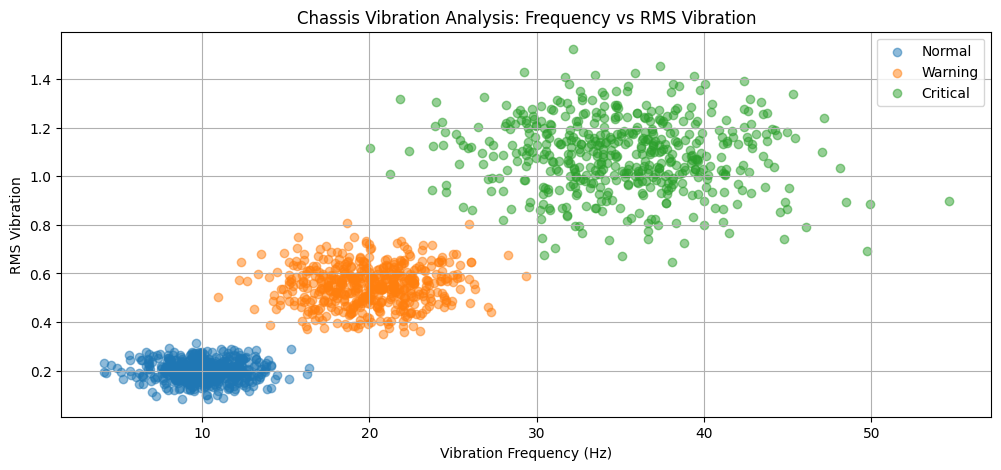

In [ ]:
plt.figure(figsize=(12, 5))

for condition in ["Normal", "Warning", "Critical"]:
    subset = df[df["condition"] == condition]
    plt.scatter(
        subset["frequency"],
        subset["rms_vibration"],
        label=condition,
        alpha=0.5
    )

plt.xlabel("Vibration Frequency (Hz)")
plt.ylabel("RMS Vibration")
plt.title("Chassis Vibration Analysis: Frequency vs RMS Vibration")
plt.legend()
plt.grid(True)
plt.show()

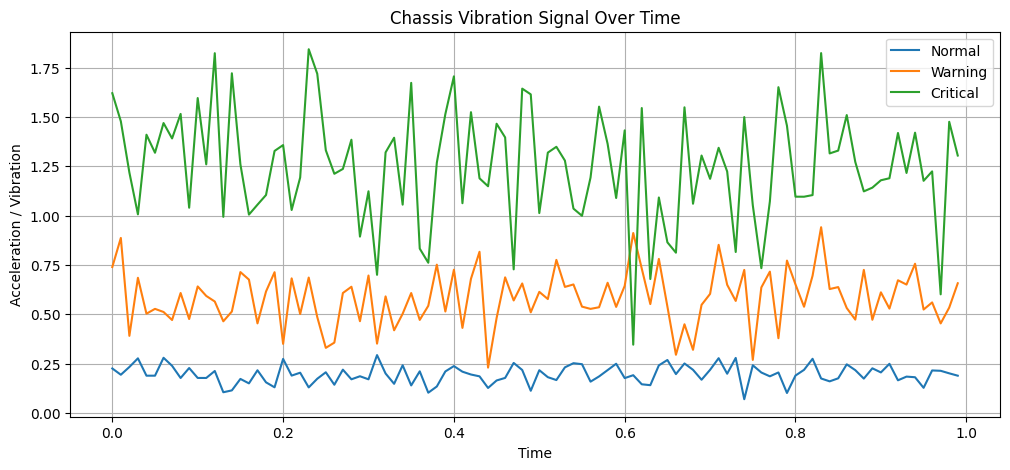

In [ ]:
plt.figure(figsize=(12, 5))

for condition in ["Normal", "Warning", "Critical"]:
    subset = df[df["condition"] == condition].sort_values("time")

    plt.plot(
        subset["time"].iloc[:100],
        subset["acceleration"].iloc[:100],
        label=condition
    )

plt.xlabel("Time")
plt.ylabel("Acceleration / Vibration")
plt.title("Chassis Vibration Signal Over Time")
plt.legend()
plt.grid(True)
plt.show()

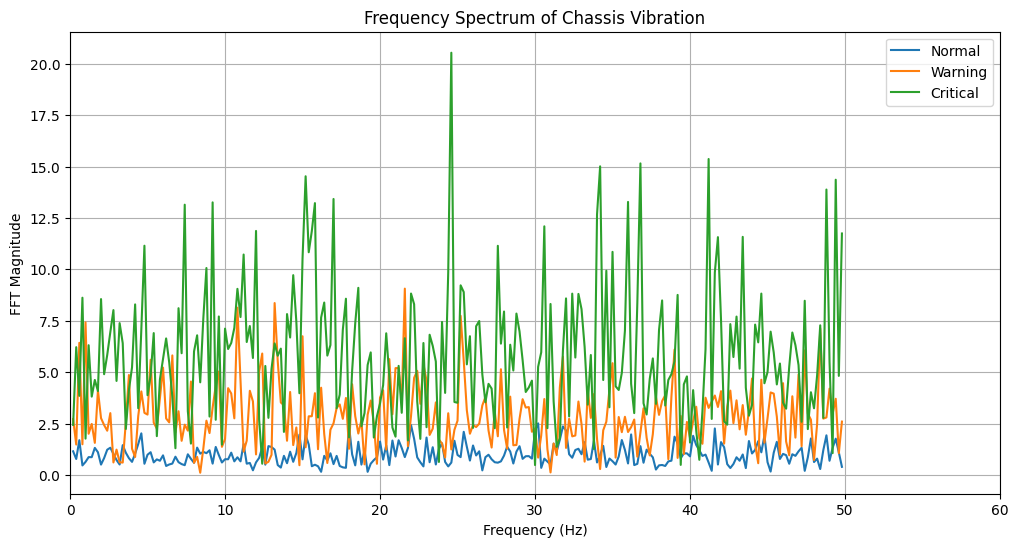

In [ ]:
# FFT analysis of vibration signals

conditions = ["Normal", "Warning", "Critical"]

plt.figure(figsize=(12, 6))

for condition in conditions:
    signal = df[df["condition"] == condition]["acceleration"].values[:500]

    # Remove the average value
    signal = signal - np.mean(signal)

    # Apply FFT
    fft_result = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(len(signal), d=0.01)

    # Take only positive frequencies
    positive = frequencies > 0

    magnitude = np.abs(fft_result)

    plt.plot(
        frequencies[positive],
        magnitude[positive],
        label=condition
    )

plt.xlim(0, 60)
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT Magnitude")
plt.title("Frequency Spectrum of Chassis Vibration")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Select features and target

X = df[["acceleration", "frequency", "rms_vibration"]]
y = df["condition"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1200
Testing samples: 300


In [ ]:
# Create and train the Random Forest model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
# Make predictions on the test data

y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0


In [ ]:
# Classification report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       100
      Normal       1.00      1.00      1.00       100
     Warning       1.00      1.00      1.00       100

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



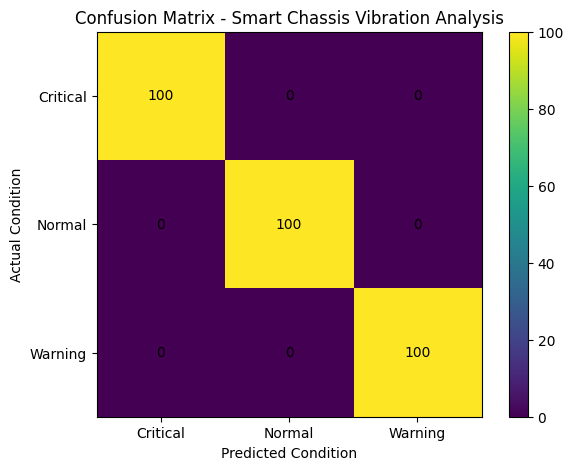

In [ ]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1, 2], ["Critical", "Normal", "Warning"])
plt.yticks([0, 1, 2], ["Critical", "Normal", "Warning"])

plt.xlabel("Predicted Condition")
plt.ylabel("Actual Condition")
plt.title("Confusion Matrix - Smart Chassis Vibration Analysis")

# Add values inside the matrix
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:
# Smart Chassis Safety Telltale

def chassis_telltale(acceleration, frequency, rms_vibration):
    sample = pd.DataFrame({
        "acceleration": [acceleration],
        "frequency": [frequency],
        "rms_vibration": [rms_vibration]
    })

    prediction = model.predict(sample)[0]

    if prediction == "Normal":
        print("🟢 CHASSIS STATUS: NORMAL")
        print("Vibration level is within the normal range.")

    elif prediction == "Warning":
        print("🟡 CHASSIS STATUS: WARNING")
        print("Abnormal vibration detected. Inspection may be required.")

    else:
        print("🔴 CHASSIS STATUS: CRITICAL")
        print("Severe abnormal vibration detected. Immediate inspection recommended.")

    return prediction

In [ ]:
# Test the safety telltale

result = chassis_telltale(
    acceleration=1.20,
    frequency=35,
    rms_vibration=1.10
)

🔴 CHASSIS STATUS: CRITICAL
Severe abnormal vibration detected. Immediate inspection recommended.


In [ ]:
# Test all three chassis conditions

print("TEST 1")
chassis_telltale(
    acceleration=0.20,
    frequency=10,
    rms_vibration=0.20
)

print("\nTEST 2")
chassis_telltale(
    acceleration=0.60,
    frequency=20,
    rms_vibration=0.55
)

print("\nTEST 3")
chassis_telltale(
    acceleration=1.20,
    frequency=35,
    rms_vibration=1.10
)

TEST 1
🟢 CHASSIS STATUS: NORMAL
Vibration level is within the normal range.

TEST 2
🟡 CHASSIS STATUS: WARNING
Abnormal vibration detected. Inspection may be required.

TEST 3
🔴 CHASSIS STATUS: CRITICAL
Severe abnormal vibration detected. Immediate inspection recommended.


'Critical'

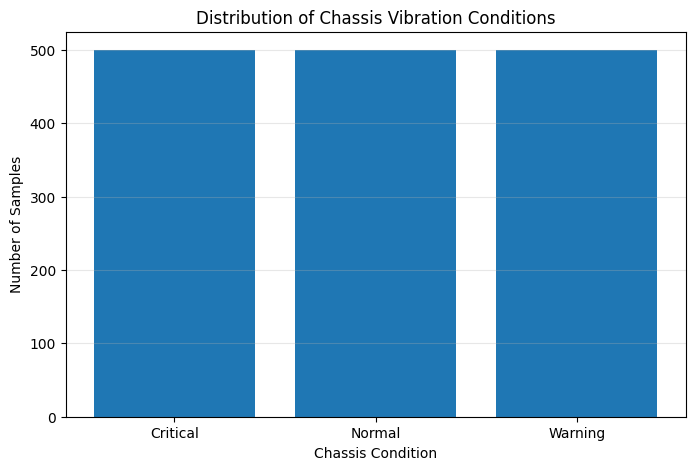

In [ ]:
# Chassis condition distribution

condition_counts = df["condition"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    condition_counts.index,
    condition_counts.values
)

plt.xlabel("Chassis Condition")
plt.ylabel("Number of Samples")
plt.title("Distribution of Chassis Vibration Conditions")
plt.grid(axis="y", alpha=0.3)

plt.show()

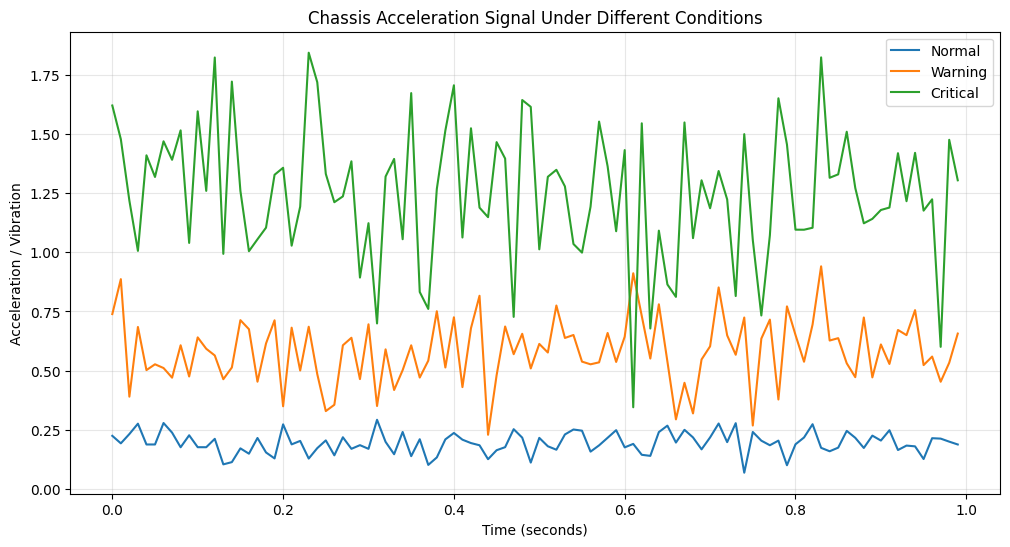

In [ ]:
# Acceleration vs Time for different chassis conditions

plt.figure(figsize=(12, 6))

for condition in ["Normal", "Warning", "Critical"]:
    subset = df[df["condition"] == condition].sort_values("time")

    plt.plot(
        subset["time"].iloc[:100],
        subset["acceleration"].iloc[:100],
        label=condition
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration / Vibration")
plt.title("Chassis Acceleration Signal Under Different Conditions")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

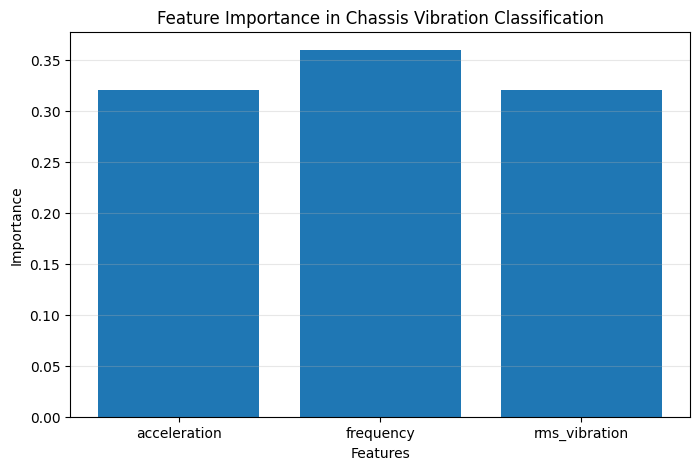

acceleration: 0.3205
frequency: 0.3596
rms_vibration: 0.3199


In [ ]:
# Feature Importance of the Random Forest Model

features = ["acceleration", "frequency", "rms_vibration"]

importance = model.feature_importances_

plt.figure(figsize=(8, 5))

plt.bar(features, importance)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Chassis Vibration Classification")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Display importance values
for feature, value in zip(features, importance):
    print(f"{feature}: {value:.4f}")

In [ ]:
# Save the Smart Chassis Vibration Dataset

file_name = "Smart_Chassis_Vibration_Dataset.csv"

df.to_csv(file_name, index=False)

print("Dataset saved successfully!")
print("File name:", file_name)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Dataset saved successfully!
File name: Smart_Chassis_Vibration_Dataset.csv
Number of rows: 1500
Number of columns: 5


In [ ]:
# Live Chassis Vibration Monitoring Demo

test_cases = [
    {
        "name": "Normal Driving",
        "acceleration": 0.20,
        "frequency": 10,
        "rms_vibration": 0.20
    },
    {
        "name": "Abnormal Vibration",
        "acceleration": 0.60,
        "frequency": 20,
        "rms_vibration": 0.55
    },
    {
        "name": "Severe Vibration",
        "acceleration": 1.20,
        "frequency": 35,
        "rms_vibration": 1.10
    }
]

print("SMART CHASSIS VIBRATION MONITOR")
print("=" * 45)

for case in test_cases:

    result = chassis_telltale(
        acceleration=case["acceleration"],
        frequency=case["frequency"],
        rms_vibration=case["rms_vibration"]
    )

    print("Test Case:", case["name"])
    print("-" * 45)

SMART CHASSIS VIBRATION MONITOR
🟢 CHASSIS STATUS: NORMAL
Vibration level is within the normal range.
Test Case: Normal Driving
---------------------------------------------
🟡 CHASSIS STATUS: WARNING
Abnormal vibration detected. Inspection may be required.
Test Case: Abnormal Vibration
---------------------------------------------
🔴 CHASSIS STATUS: CRITICAL
Severe abnormal vibration detected. Immediate inspection recommended.
Test Case: Severe Vibration
---------------------------------------------


In [ ]:
# Model Performance Summary

performance = pd.DataFrame({
    "Metric": [
        "Dataset Size",
        "Training Samples",
        "Testing Samples",
        "Number of Features",
        "Number of Classes",
        "Model",
        "Accuracy"
    ],
    "Value": [
        len(df),
        len(X_train),
        len(X_test),
        X.shape[1],
        y.nunique(),
        "Random Forest Classifier",
        f"{accuracy * 100:.2f}%"
    ]
})

performance

,Metric,Value
0,Dataset Size,1500
1,Training Samples,1200
2,Testing Samples,300
3,Number of Features,3
4,Number of Classes,3
5,Model,Random Forest Classifier
6,Accuracy,100.00%


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


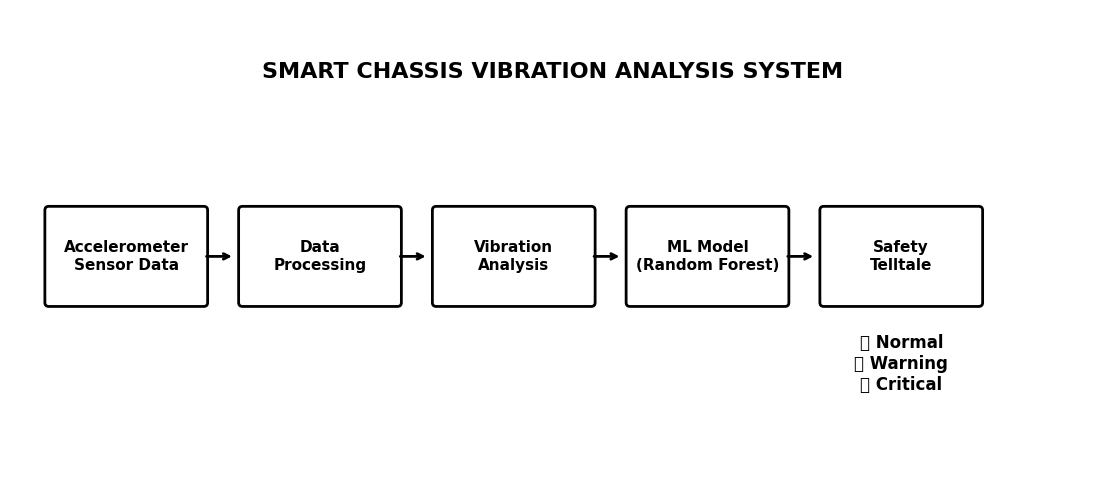

In [ ]:
# Smart Chassis Vibration Analysis - System Workflow

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 6))

ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis("off")

steps = [
    (0.5, 2.2, "Accelerometer\nSensor Data"),
    (3.0, 2.2, "Data\nProcessing"),
    (5.5, 2.2, "Vibration\nAnalysis"),
    (8.0, 2.2, "ML Model\n(Random Forest)"),
    (10.5, 2.2, "Safety\nTelltale")
]

for x, y, text in steps:
    box = FancyBboxPatch(
        (x, y),
        2.0,
        1.2,
        boxstyle="round,pad=0.05",
        linewidth=2,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)

    ax.text(
        x + 1.0,
        y + 0.6,
        text,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Arrows
for x in [2.5, 5.0, 7.5, 10.0]:
    ax.annotate(
        "",
        xy=(x + 0.4, 2.8),
        xytext=(x, 2.8),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )

# Output labels
ax.text(
    11.5,
    1.4,
    "🟢 Normal\n🟡 Warning\n🔴 Critical",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    7,
    5.2,
    "SMART CHASSIS VIBRATION ANALYSIS SYSTEM",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       100
      Normal       1.00      1.00      1.00       100
     Warning       1.00      1.00      1.00       100

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [ ]:
# Feature Importance of the Random Forest Model

features = ["acceleration", "frequency", "rms_vibration"]

importance = model.feature_importances_

for feature, value in zip(features, importance):
    print(f"{feature}: {value:.4f}")

acceleration: 0.3205
frequency: 0.3596
rms_vibration: 0.3199
